In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns #type: ignore
import os
import json

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import pandas as pd
import pickle
from datetime import datetime
import warnings
import traceback
import sys

import xgboost as xgb #type: ignore
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from datetime import timedelta

os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'
warnings.filterwarnings('ignore')
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
from helpFolder import *

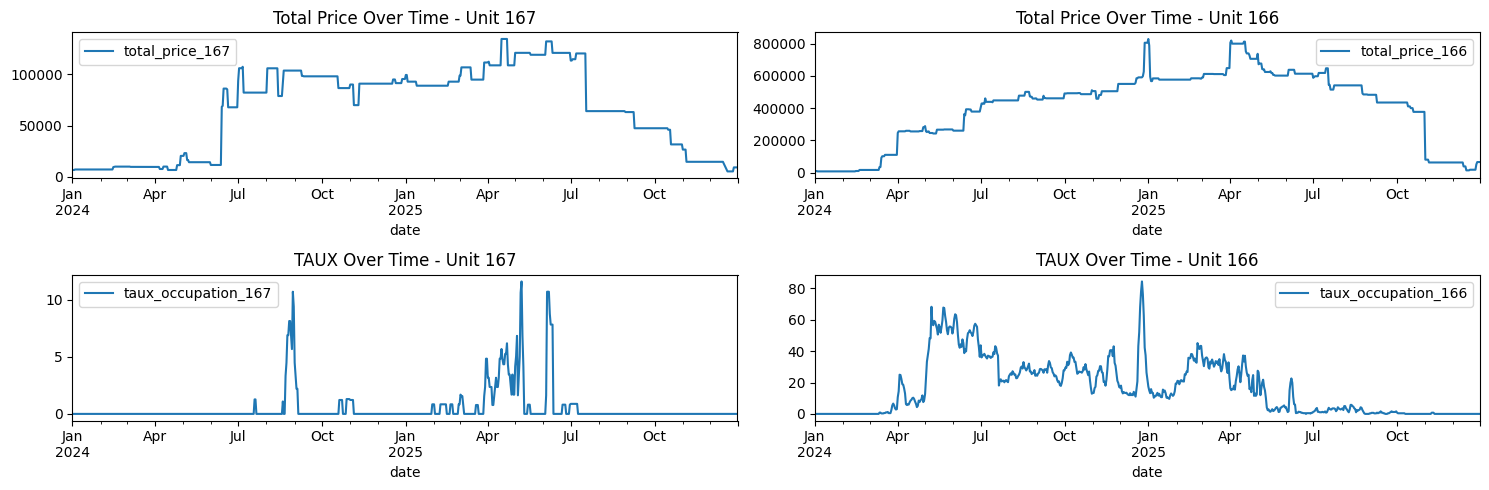

In [2]:
df_167, df_166 = prepare_and_plot_data('../../Data/UnitsFinalCSVData/FinalCSVdata.csv', 
                                       '2024-06-15', '2025-07-15')

### Train the **LSTM** models

--- Starting LSTM Pipeline for Unit 166 (predicting Occupancy Rate) ---

[Step 1/4] Splitting data with test_size=0.2...
Split complete. Test size: 0.20
Target column: taux_occupation_166
Training set range: 2024-06-15 00:00:00 to 2025-04-26 00:00:00 (316 samples)
Testing set range: 2025-04-27 00:00:00 to 2025-07-15 00:00:00 (80 samples)

[Step 2/4] Training and evaluating LSTM model...

Training LSTM model for target: taux_occupation_166 (predicting Occupancy Rate)
Hyperparameters: seq_len=10, batch=16, epochs=80, lr=0.001
Features used (X): ['dayofweek', 'month', 'year', 'dayofyear', 'weekofyear', 'total_price_166']

Starting Training...


Epoch [10/80], Loss: 0.045352


Epoch [20/80], Loss: 0.030640


Epoch [30/80], Loss: 0.029672


Epoch [40/80], Loss: 0.025321


Epoch [50/80], Loss: 0.022224


Epoch [60/80], Loss: 0.020428


Epoch [70/80], Loss: 0.018954


Epoch [80/80], Loss: 0.019958
Training Finished.

Model Evaluation Metrics for Occupancy Rate prediction:
Train RMSE: 10.24
Test RMSE: 37.02
Train MAE: 7.20
Test MAE: 36.53
Train R²: 0.1549
Test R²: -45.5261

[Step 3/4] Plotting results...
Plotting training loss...


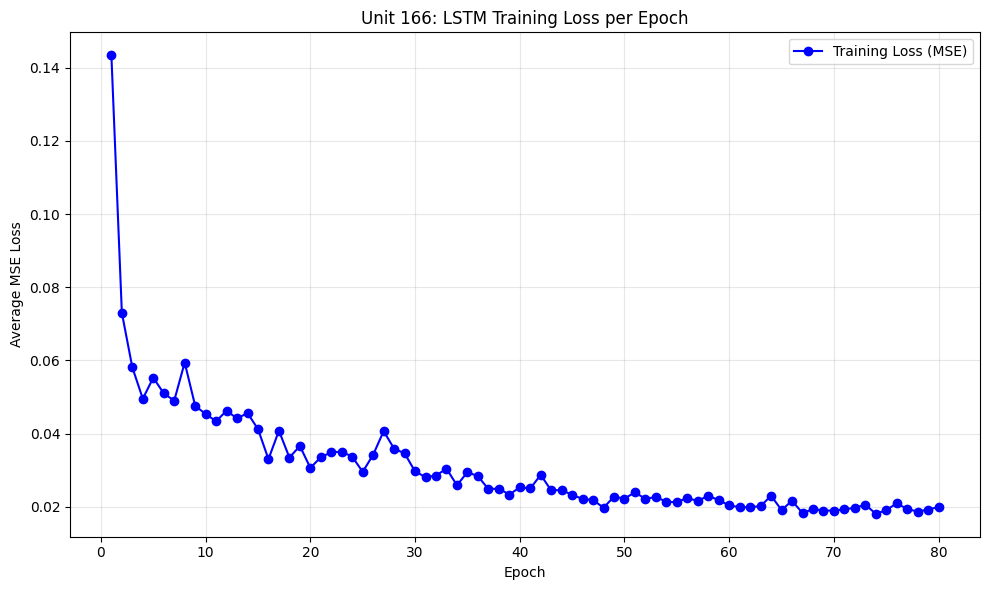

Plotting predictions on train/test split...


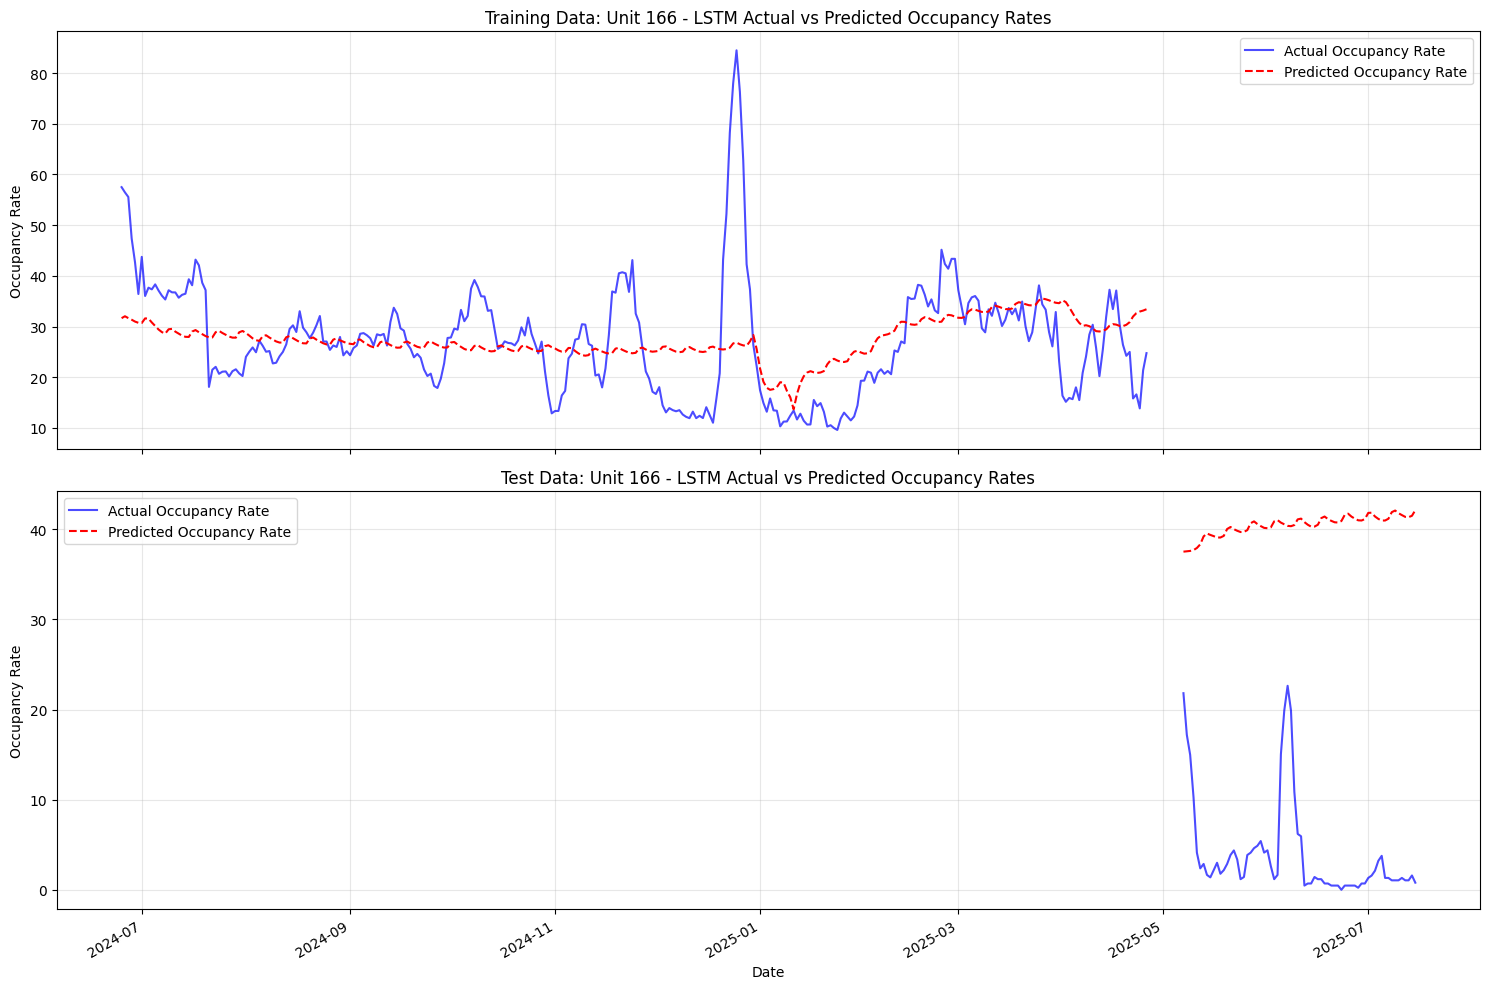

Plotting predictions on the full unit DataFrame...


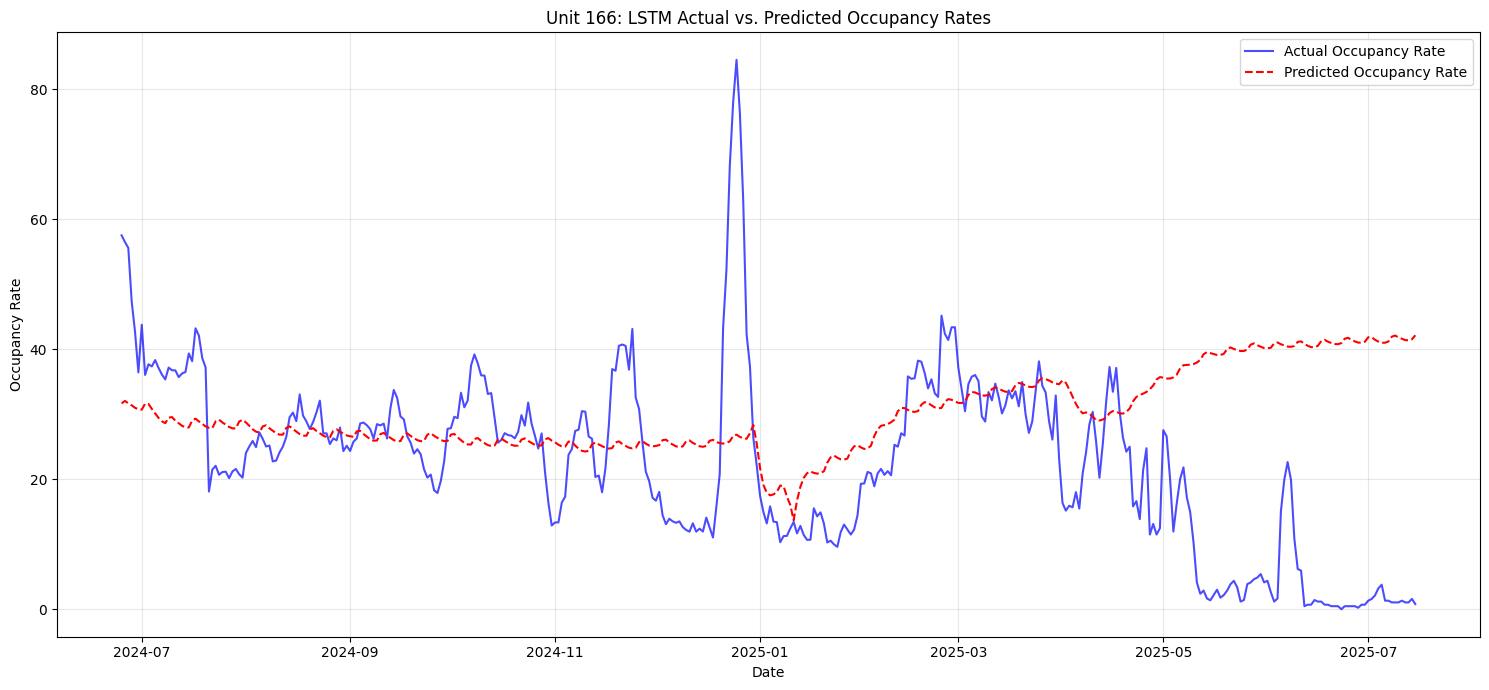


[Step 4/4] Pipeline finished for Unit 166.
--- End LSTM Pipeline ---


In [5]:
lstm_results_taux_166 = run_lstm_pipeline(
    df_166,
    '166',
    test_size=0.2,
    sequence_length=10, 
    epochs=80,
    target_type='taux'
)

--- Starting LSTM Pipeline for Unit 167 (predicting Occupancy Rate) ---

[Step 1/4] Splitting data with test_size=0.2...
Split complete. Test size: 0.20
Target column: taux_occupation_167
Training set range: 2024-06-15 00:00:00 to 2025-04-26 00:00:00 (316 samples)
Testing set range: 2025-04-27 00:00:00 to 2025-07-15 00:00:00 (80 samples)

[Step 2/4] Training and evaluating LSTM model...

Training LSTM model for target: taux_occupation_167 (predicting Occupancy Rate)
Hyperparameters: seq_len=10, batch=16, epochs=80, lr=0.001
Features used (X): ['dayofweek', 'month', 'year', 'dayofyear', 'weekofyear', 'total_price_167']

Starting Training...


Epoch [10/80], Loss: 0.038407


Epoch [20/80], Loss: 0.028685


Epoch [30/80], Loss: 0.022242


Epoch [40/80], Loss: 0.019101


Epoch [50/80], Loss: 0.018808


Epoch [60/80], Loss: 0.015960


Epoch [70/80], Loss: 0.016387


Epoch [80/80], Loss: 0.016321
Training Finished.

Model Evaluation Metrics for Occupancy Rate prediction:
Train RMSE: 1.37
Test RMSE: 3.36
Train MAE: 0.80
Test MAE: 2.85
Train R²: 0.3472
Test R²: -0.0566

[Step 3/4] Plotting results...
Plotting training loss...


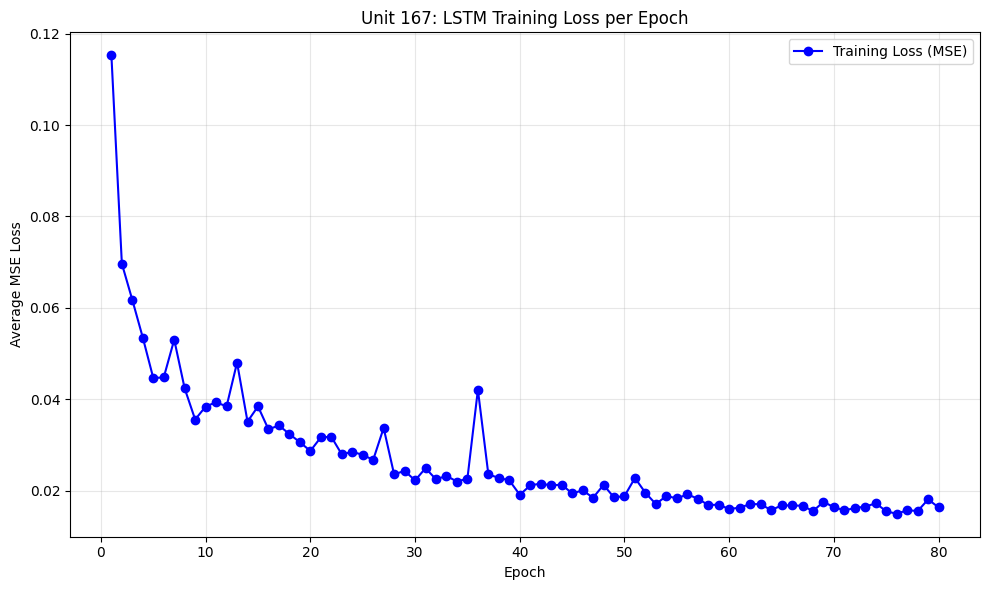

Plotting predictions on train/test split...


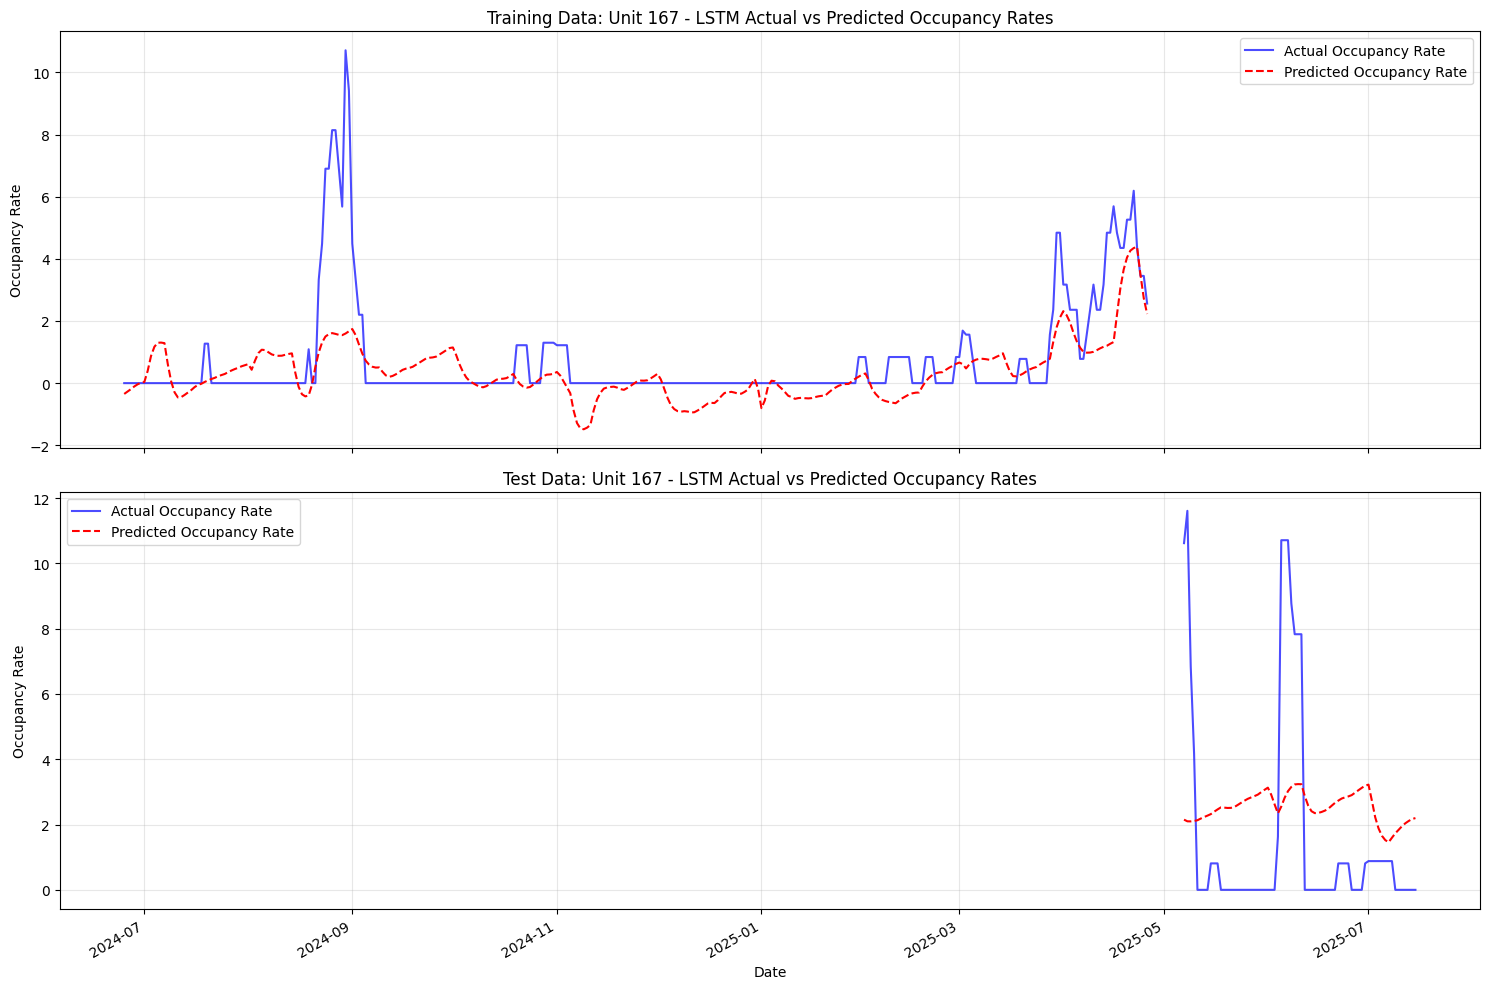

Plotting predictions on the full unit DataFrame...


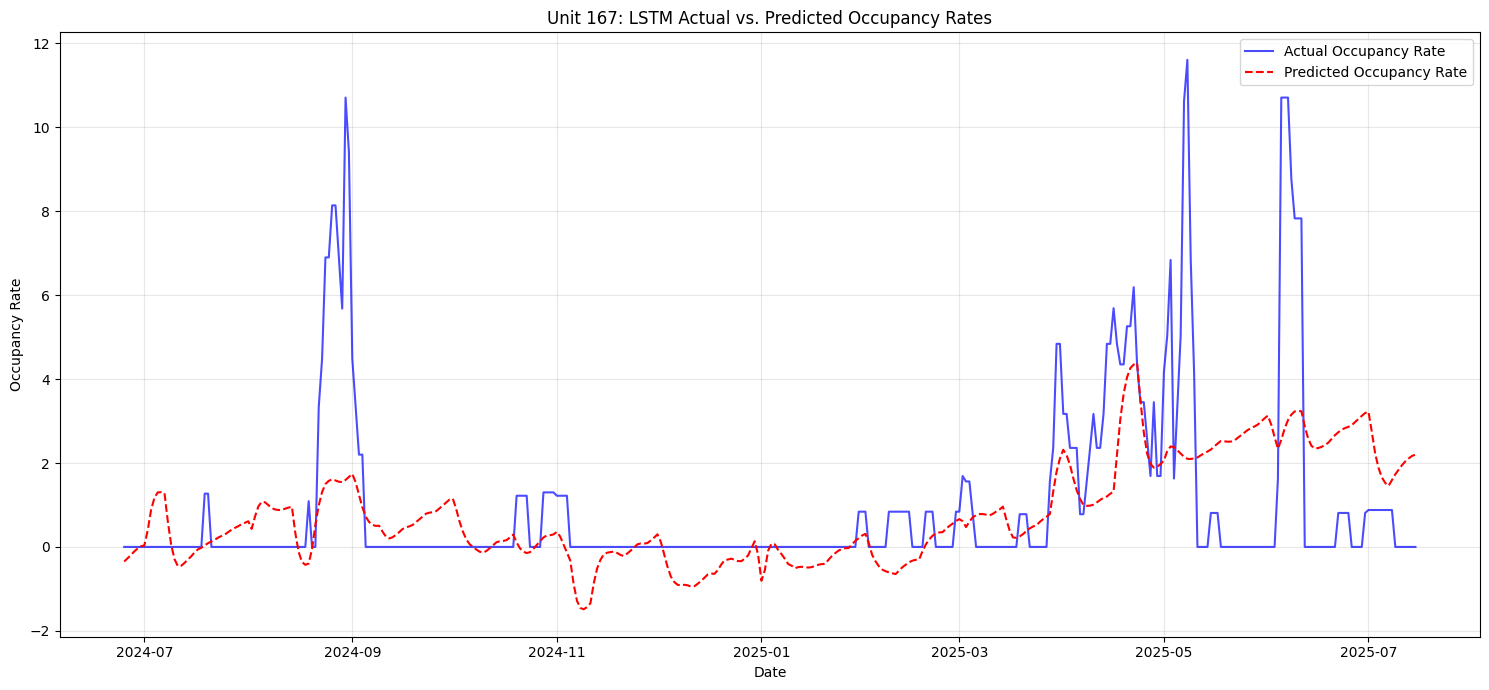


[Step 4/4] Pipeline finished for Unit 167.
--- End LSTM Pipeline ---


In [6]:
lstm_results_taux_167 = run_lstm_pipeline(
    df_167,
    '167',
    test_size=0.2,
    sequence_length=10, 
    epochs=80,
    target_type='taux'
)


In [5]:
save_lstm_model(
    lstm_results = lstm_results_taux_166,
    folder_path = '../TrainedModels/UnitsBasedModels/PredictTaux/LSTMModels',
    model_name = 'lstm_model_166_taux',
)

save_lstm_model(
    lstm_results = lstm_results_taux_167,
    folder_path = '../TrainedModels/UnitsBasedModels/PredictTaux/LSTMModels',
    model_name = 'lstm_model_167_taux',
)

NameError: name 'lstm_results_taux_166' is not defined

In [5]:
result_lstm_taux_166 = load_lstm_model(
    folder_path='../TrainedModels/UnitsBasedModels/PredictTaux/LSTMModels',
    model_name='lstm_model_166_taux',
)

Metadata successfully loaded from ../TrainedModels/UnitsBasedModels/PredictTaux/LSTMModels\lstm_model_166_taux_metadata.json
Target column extracted: taux_occupation_166
Target type extracted: taux
LSTMModel instantiated with parameters from metadata.
Model state dictionary successfully loaded from ../TrainedModels/UnitsBasedModels/PredictTaux/LSTMModels\lstm_model_166_taux_model_state_dict.pth onto cpu
Feature scaler successfully loaded from ../TrainedModels/UnitsBasedModels/PredictTaux/LSTMModels\lstm_model_166_taux_feature_scaler.pkl
Target scaler successfully loaded from ../TrainedModels/UnitsBasedModels/PredictTaux/LSTMModels\lstm_model_166_taux_target_scaler.pkl

Loading process finished.


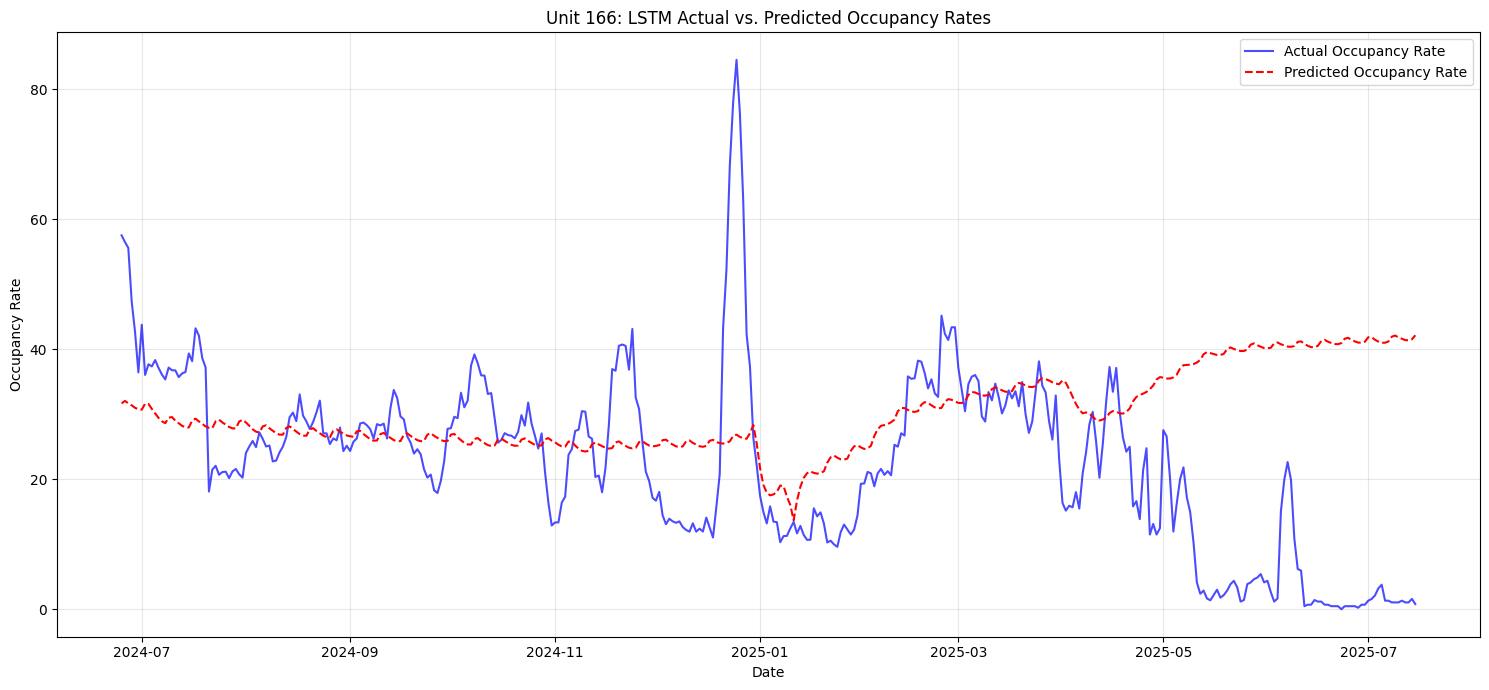

,Actual,Predicted
date,,
2024-06-25,57.50,31.656654
2024-06-26,56.47,32.033352
2024-06-27,55.56,31.668612
2024-06-28,47.36,31.351538
2024-06-29,42.66,30.981260
...,...,...
2025-07-11,1.32,41.586025
2025-07-12,1.05,41.388657
2025-07-13,1.05,41.354134


In [6]:
plot_lstm_predictions_on_dataframe(
    df=df_166,
    unit_id='166',
    model=result_lstm_taux_166['model'],
    feature_scaler=result_lstm_taux_166['feature_scaler'],
    target_scaler=result_lstm_taux_166['target_scaler'],
    sequence_length=result_lstm_taux_166['metadata']['sequence_length'],
    target_col = result_lstm_taux_166['metadata']['target_col'],
    device='cuda' if torch.cuda.is_available() else 'cpu'
)

In [7]:
predict_single_step_lstm(
    target_date_str='2025-06-15',
    taux_or_price_target=1000,
    df_history=df_166,
    loaded_model_data=result_lstm_taux_166,
    unit_id='166',
    device= 'cpu',
    target_type='taux',
)


--- Predicting taux for Unit 166 on 2025-06-15 ---
Generated features for target date: {'dayofweek': 6, 'month': 6, 'year': 2025, 'dayofyear': 166, 'weekofyear': 24, 'total_price_166': 1000}
Fetching history from 2025-06-06 to 2025-06-14
Expected feature order: ['dayofweek', 'month', 'year', 'dayofyear', 'weekofyear', 'total_price_166']
Scaling sequence of shape: (10, 6)
Input tensor shape: torch.Size([1, 10, 6])
Scaled prediction shape: torch.Size([1, 1])
Predicted taux (Unit 166) for 2025-06-15: 39.86


39.85706

In [10]:
best_taux_occupation, max_predicted_price = find_max_price_for_date_lstm(
    loaded_model_data=result_lstm_taux_166,
    target_date_str='2025-06-20',
    unit_id='166',
    df_history=df_166,
    device='cuda' if torch.cuda.is_available() else 'cpu',
    min_taux=200000,
    max_taux=600000,
    step=10000,
    target_type='taux'
)


Searching for optimal price input that maximizes taux
for LSTM model (unit 166) on 2025-06-20...
Range: 200000-600000, step: 10000


Testing total_price values:   5%|▍         | 2/41 [00:00<00:02, 17.86it/s]


--- Predicting taux for Unit 166 on 2025-06-20 ---
Generated features for target date: {'dayofweek': 4, 'month': 6, 'year': 2025, 'dayofyear': 171, 'weekofyear': 25, 'total_price_166': 200000.0}
Fetching history from 2025-06-11 to 2025-06-19
Expected feature order: ['dayofweek', 'month', 'year', 'dayofyear', 'weekofyear', 'total_price_166']
Scaling sequence of shape: (10, 6)
Input tensor shape: torch.Size([1, 10, 6])
Scaled prediction shape: torch.Size([1, 1])
Predicted taux (Unit 166) for 2025-06-20: 40.34

--- Predicting taux for Unit 166 on 2025-06-20 ---
Generated features for target date: {'dayofweek': 4, 'month': 6, 'year': 2025, 'dayofyear': 171, 'weekofyear': 25, 'total_price_166': 210000.0}
Fetching history from 2025-06-11 to 2025-06-19
Expected feature order: ['dayofweek', 'month', 'year', 'dayofyear', 'weekofyear', 'total_price_166']
Scaling sequence of shape: (10, 6)
Input tensor shape: torch.Size([1, 10, 6])
Scaled prediction shape: torch.Size([1, 1])
Predicted taux (Unit

Testing total_price values:  51%|█████     | 21/41 [00:00<00:00, 79.99it/s]

Scaled prediction shape: torch.Size([1, 1])
Predicted taux (Unit 166) for 2025-06-20: 40.40

--- Predicting taux for Unit 166 on 2025-06-20 ---
Generated features for target date: {'dayofweek': 4, 'month': 6, 'year': 2025, 'dayofyear': 171, 'weekofyear': 25, 'total_price_166': 270000.0}
Fetching history from 2025-06-11 to 2025-06-19
Expected feature order: ['dayofweek', 'month', 'year', 'dayofyear', 'weekofyear', 'total_price_166']
Scaling sequence of shape: (10, 6)
Input tensor shape: torch.Size([1, 10, 6])
Scaled prediction shape: torch.Size([1, 1])
Predicted taux (Unit 166) for 2025-06-20: 40.41

--- Predicting taux for Unit 166 on 2025-06-20 ---
Generated features for target date: {'dayofweek': 4, 'month': 6, 'year': 2025, 'dayofyear': 171, 'weekofyear': 25, 'total_price_166': 280000.0}
Fetching history from 2025-06-11 to 2025-06-19
Expected feature order: ['dayofweek', 'month', 'year', 'dayofyear', 'weekofyear', 'total_price_166']
Scaling sequence of shape: (10, 6)
Input tensor sh

Testing total_price values: 100%|██████████| 41/41 [00:00<00:00, 91.11it/s] 

Scaled prediction shape: torch.Size([1, 1])
Predicted taux (Unit 166) for 2025-06-20: 40.70

--- Predicting taux for Unit 166 on 2025-06-20 ---
Generated features for target date: {'dayofweek': 4, 'month': 6, 'year': 2025, 'dayofyear': 171, 'weekofyear': 25, 'total_price_166': 550000.0}
Fetching history from 2025-06-11 to 2025-06-19
Expected feature order: ['dayofweek', 'month', 'year', 'dayofyear', 'weekofyear', 'total_price_166']
Scaling sequence of shape: (10, 6)
Input tensor shape: torch.Size([1, 10, 6])
Scaled prediction shape: torch.Size([1, 1])
Predicted taux (Unit 166) for 2025-06-20: 40.71

--- Predicting taux for Unit 166 on 2025-06-20 ---
Generated features for target date: {'dayofweek': 4, 'month': 6, 'year': 2025, 'dayofyear': 171, 'weekofyear': 25, 'total_price_166': 560000.0}
Fetching history from 2025-06-11 to 2025-06-19
Expected feature order: ['dayofweek', 'month', 'year', 'dayofyear', 'weekofyear', 'total_price_166']
Scaling sequence of shape: (10, 6)
Input tensor sh

In [15]:
predict_single_step_lstm(
    target_date_str='2025-01-01',
    taux_or_price_target=200000,
    df_history=df_166,
    loaded_model_data=result_lstm_taux_166,
    unit_id='166',
    device= 'cpu',
    target_type='taux',
)


--- Predicting taux for Unit 166 on 2025-01-01 ---
Generated features for target date: {'dayofweek': 2, 'month': 1, 'year': 2025, 'dayofyear': 1, 'weekofyear': 1, 'total_price_166': 200000}
Fetching history from 2024-12-23 to 2024-12-31
Expected feature order: ['dayofweek', 'month', 'year', 'dayofyear', 'weekofyear', 'total_price_166']
Scaling sequence of shape: (10, 6)
Input tensor shape: torch.Size([1, 10, 6])
Scaled prediction shape: torch.Size([1, 1])
Predicted taux (Unit 166) for 2025-01-01: 19.40


19.399452

--- Starting LSTM Pipeline for Unit 167 (predicting Price) ---

[Step 1/4] Splitting data with test_size=0.2...
Split complete. Test size: 0.20
Target column: total_price_167
Training set range: 2024-06-15 00:00:00 to 2025-04-26 00:00:00 (316 samples)
Testing set range: 2025-04-27 00:00:00 to 2025-07-15 00:00:00 (80 samples)

[Step 2/4] Training and evaluating LSTM model...

Training LSTM model for target: total_price_167 (predicting Price)
Hyperparameters: seq_len=5, batch=16, epochs=80, lr=0.001
Features used (X): ['dayofweek', 'month', 'year', 'dayofyear', 'weekofyear', 'taux_occupation_167']

Starting Training...


Epoch [10/80], Loss: 0.049994


Epoch [20/80], Loss: 0.035321


Epoch [30/80], Loss: 0.024894


Epoch [40/80], Loss: 0.023257


Epoch [50/80], Loss: 0.021641


Epoch [60/80], Loss: 0.017124


Epoch [70/80], Loss: 0.018710


Epoch [80/80], Loss: 0.019269
Training Finished.

Model Evaluation Metrics for Price prediction:
Train RMSE: 8253.11
Test RMSE: 13834.85
Train MAE: 6139.03
Test MAE: 12656.27
Train R²: 0.4920
Test R²: -10.9533

[Step 3/4] Plotting results...
Plotting training loss...


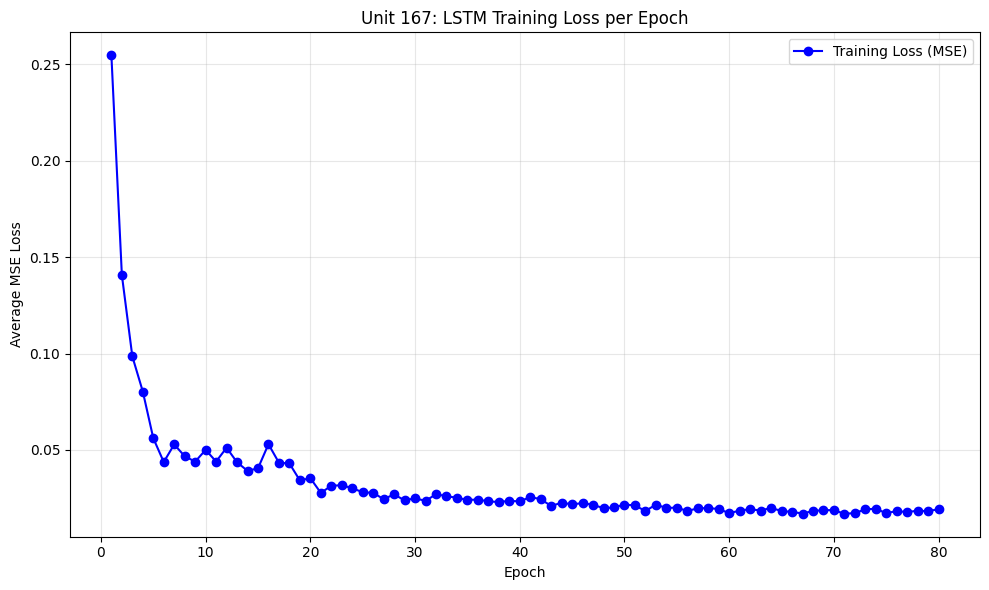

Plotting predictions on train/test split...


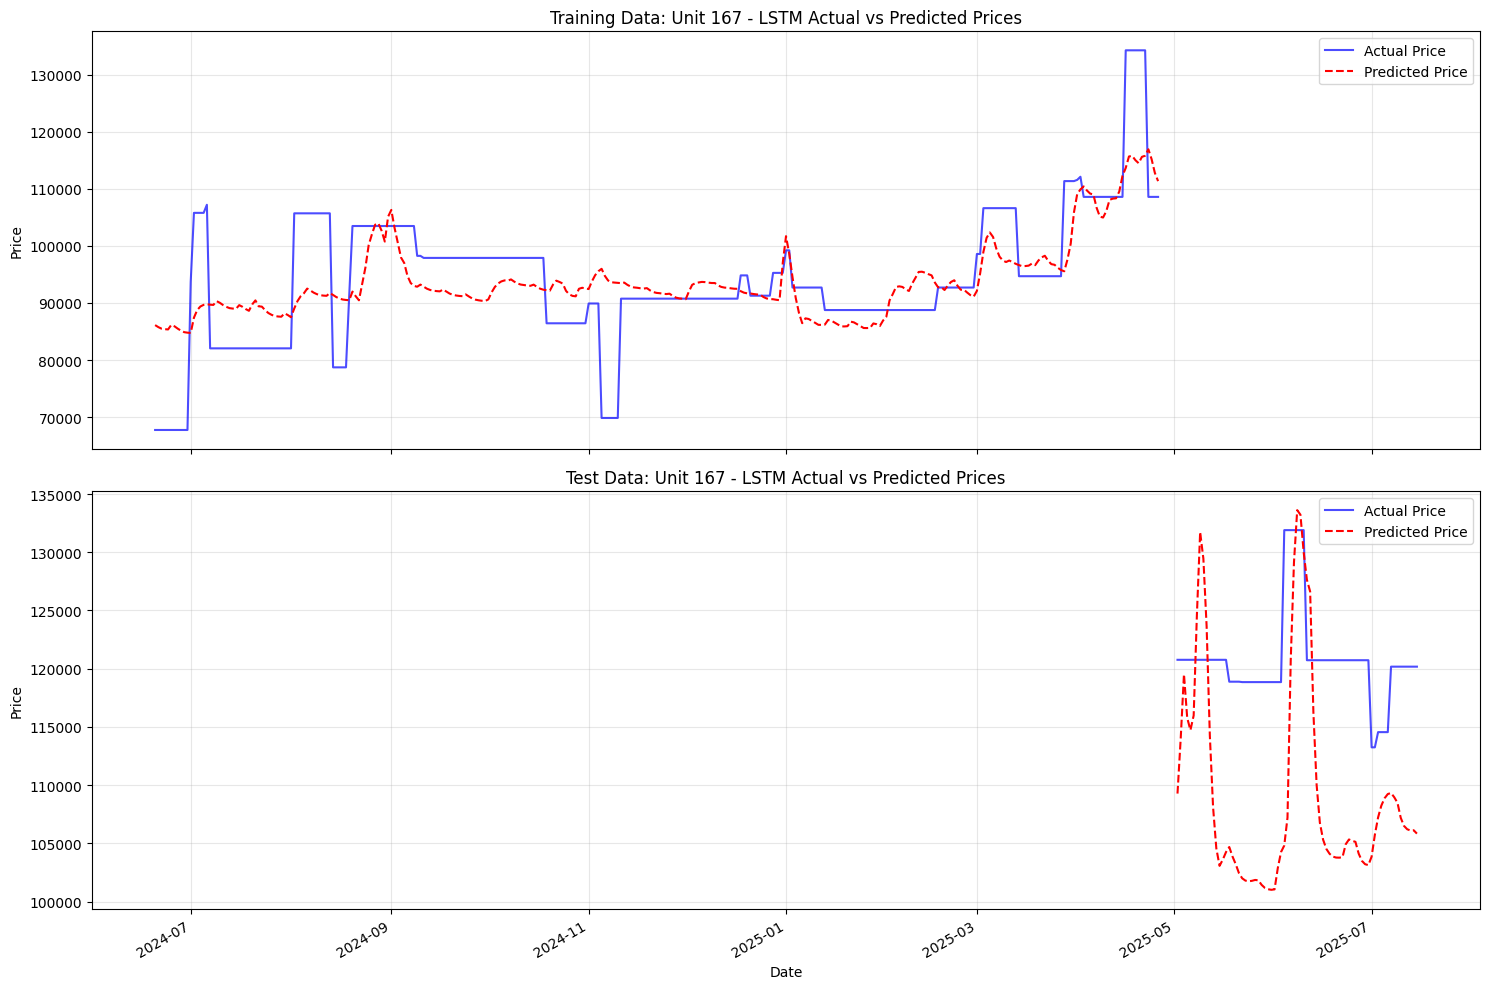

Plotting predictions on the full unit DataFrame...


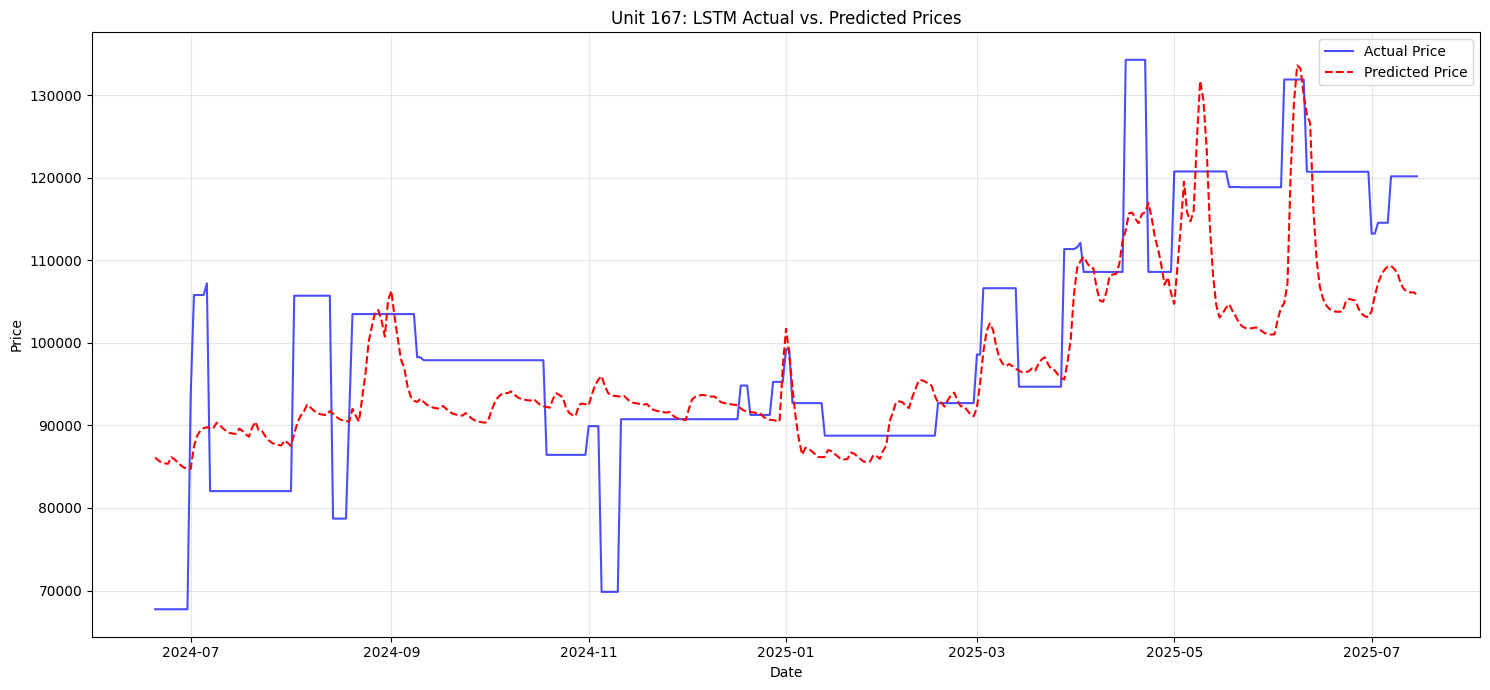


[Step 4/4] Pipeline finished for Unit 167.
--- End LSTM Pipeline ---


In [16]:
lstm_results_price_167 = run_lstm_pipeline(
    df_167,
    '167',
    test_size=0.2,
    sequence_length=5, 
    epochs=80,
    target_type='price'
)

--- Starting LSTM Pipeline for Unit 166 (predicting Price) ---

[Step 1/4] Splitting data with test_size=0.2...
Split complete. Test size: 0.20
Target column: total_price_166
Training set range: 2024-06-15 00:00:00 to 2025-04-26 00:00:00 (316 samples)
Testing set range: 2025-04-27 00:00:00 to 2025-07-15 00:00:00 (80 samples)

[Step 2/4] Training and evaluating LSTM model...

Training LSTM model for target: total_price_166 (predicting Price)
Hyperparameters: seq_len=5, batch=16, epochs=80, lr=0.001
Features used (X): ['dayofweek', 'month', 'year', 'dayofyear', 'weekofyear', 'taux_occupation_166']

Starting Training...


Epoch [10/80], Loss: 0.044376


Epoch [20/80], Loss: 0.028205


Epoch [30/80], Loss: 0.026583


Epoch [40/80], Loss: 0.013203


Epoch [50/80], Loss: 0.012528


Epoch [60/80], Loss: 0.009102


Epoch [70/80], Loss: 0.013172


Epoch [80/80], Loss: 0.010280
Training Finished.

Model Evaluation Metrics for Price prediction:
Train RMSE: 32408.20
Test RMSE: 284597.94
Train MAE: 24531.77
Test MAE: 277472.44
Train R²: 0.9008
Test R²: -228.2741

[Step 3/4] Plotting results...
Plotting training loss...


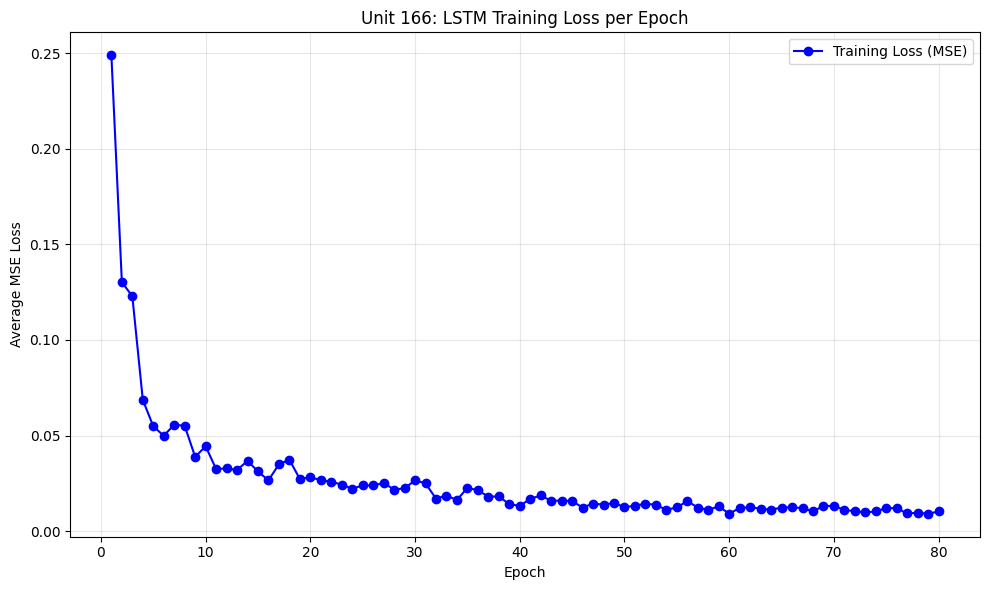

Plotting predictions on train/test split...


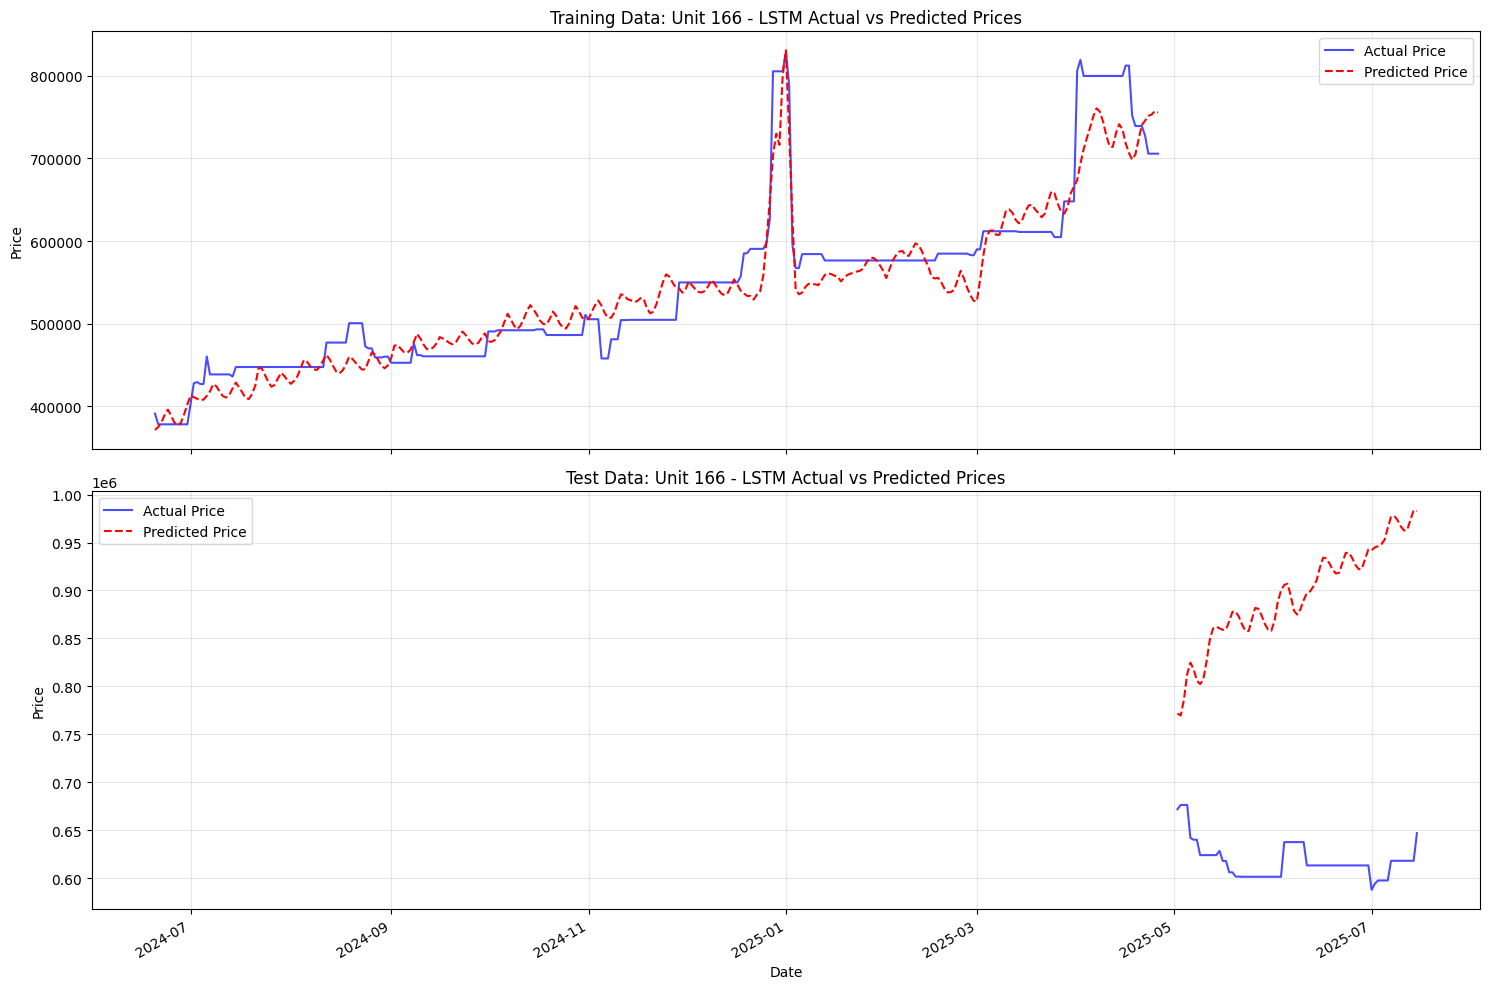

Plotting predictions on the full unit DataFrame...


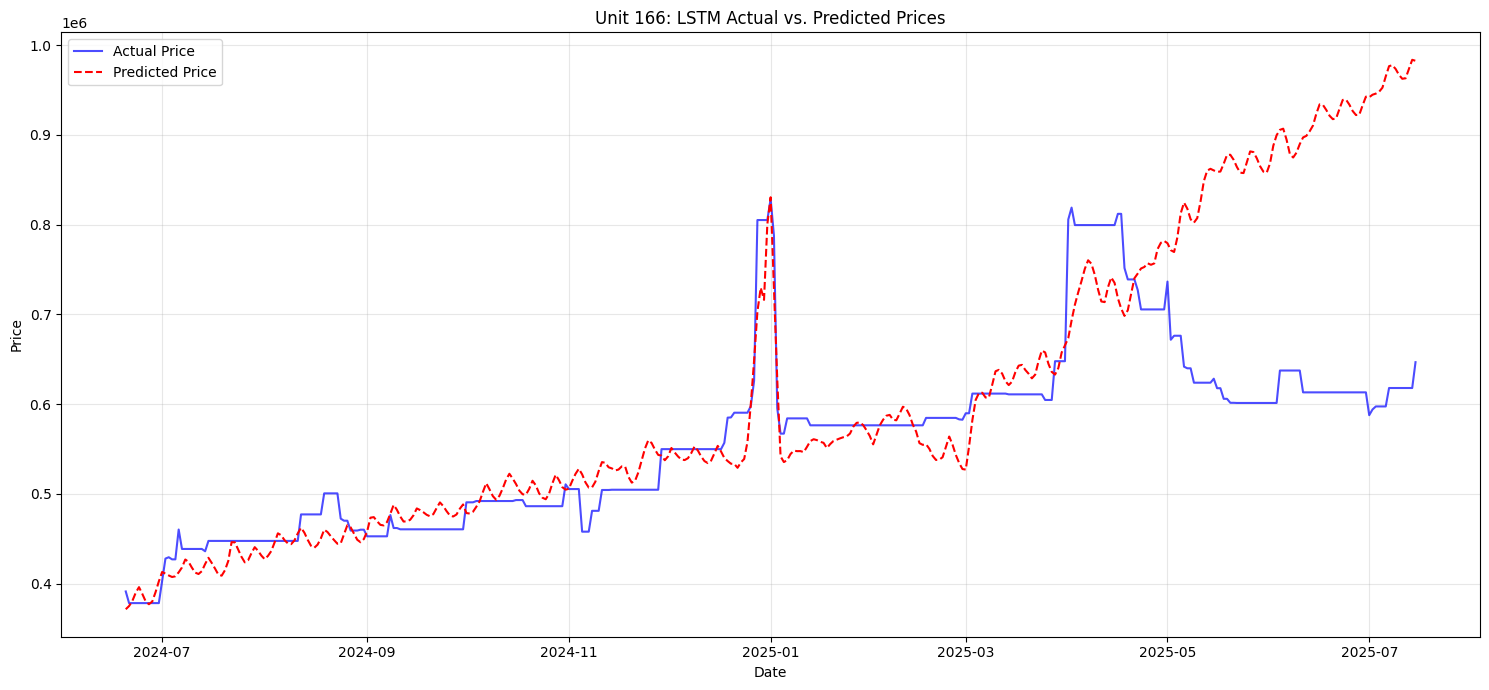


[Step 4/4] Pipeline finished for Unit 166.
--- End LSTM Pipeline ---


In [17]:
lstm_results_price_166 = run_lstm_pipeline(
    df_166,
    '166',
    test_size=0.2,
    sequence_length=5, 
    epochs=80,
    target_type='price'
)

In [18]:
save_lstm_model(
    lstm_results = lstm_results_price_166,
    folder_path = '../TrainedModels//UnitsBasedModels/PredictPrice/LSTMModels',
    model_name = 'lstm_model_166_price',
)

save_lstm_model(
    lstm_results = lstm_results_price_167,
    folder_path = '../TrainedModels//UnitsBasedModels/PredictPrice/LSTMModels',
    model_name = 'lstm_model_167_price',
)

Created directory: ../TrainedModels//UnitsBasedModels/PredictPrice/LSTMModels
Model state dictionary successfully saved to ../TrainedModels//UnitsBasedModels/PredictPrice/LSTMModels\lstm_model_166_price_model_state_dict.pth
Feature scaler successfully saved to ../TrainedModels//UnitsBasedModels/PredictPrice/LSTMModels\lstm_model_166_price_feature_scaler.pkl
Target scaler successfully saved to ../TrainedModels//UnitsBasedModels/PredictPrice/LSTMModels\lstm_model_166_price_target_scaler.pkl
Model metadata saved to ../TrainedModels//UnitsBasedModels/PredictPrice/LSTMModels\lstm_model_166_price_metadata.json
Model state dictionary successfully saved to ../TrainedModels//UnitsBasedModels/PredictPrice/LSTMModels\lstm_model_167_price_model_state_dict.pth
Feature scaler successfully saved to ../TrainedModels//UnitsBasedModels/PredictPrice/LSTMModels\lstm_model_167_price_feature_scaler.pkl
Target scaler successfully saved to ../TrainedModels//UnitsBasedModels/PredictPrice/LSTMModels\lstm_model_

{'model_state_dict': '../TrainedModels//UnitsBasedModels/PredictPrice/LSTMModels\\lstm_model_167_price_model_state_dict.pth',
 'feature_scaler': '../TrainedModels//UnitsBasedModels/PredictPrice/LSTMModels\\lstm_model_167_price_feature_scaler.pkl',
 'target_scaler': '../TrainedModels//UnitsBasedModels/PredictPrice/LSTMModels\\lstm_model_167_price_target_scaler.pkl',
 'metadata': '../TrainedModels//UnitsBasedModels/PredictPrice/LSTMModels\\lstm_model_167_price_metadata.json'}

In [3]:
result_lstm_taux_166 = load_lstm_model(
    folder_path='../TrainedModels/UnitsBasedModels/PredictTaux/LSTMModels',
    model_name='lstm_model_166_taux',
)

Metadata successfully loaded from ../TrainedModels/UnitsBasedModels/PredictTaux/LSTMModels\lstm_model_166_taux_metadata.json
Target column extracted: taux_occupation_166
Target type extracted: taux
LSTMModel instantiated with parameters from metadata.
Model state dictionary successfully loaded from ../TrainedModels/UnitsBasedModels/PredictTaux/LSTMModels\lstm_model_166_taux_model_state_dict.pth onto cpu
Feature scaler successfully loaded from ../TrainedModels/UnitsBasedModels/PredictTaux/LSTMModels\lstm_model_166_taux_feature_scaler.pkl
Target scaler successfully loaded from ../TrainedModels/UnitsBasedModels/PredictTaux/LSTMModels\lstm_model_166_taux_target_scaler.pkl

Loading process finished.


In [5]:
result_lstm_taux_167 = load_lstm_model(
    folder_path='../TrainedModels/UnitsBasedModels/PredictTaux/LSTMModels',
    model_name='lstm_model_167_taux',
)

Metadata successfully loaded from ../TrainedModels/UnitsBasedModels/PredictTaux/LSTMModels\lstm_model_167_taux_metadata.json
Target column extracted: taux_occupation_167
Target type extracted: taux
LSTMModel instantiated with parameters from metadata.
Model state dictionary successfully loaded from ../TrainedModels/UnitsBasedModels/PredictTaux/LSTMModels\lstm_model_167_taux_model_state_dict.pth onto cpu
Feature scaler successfully loaded from ../TrainedModels/UnitsBasedModels/PredictTaux/LSTMModels\lstm_model_167_taux_feature_scaler.pkl
Target scaler successfully loaded from ../TrainedModels/UnitsBasedModels/PredictTaux/LSTMModels\lstm_model_167_taux_target_scaler.pkl

Loading process finished.


In [6]:
result_lstm_price_166 = load_lstm_model(
    folder_path='../TrainedModels/UnitsBasedModels/PredictPrice/LSTMModels',
    model_name='lstm_model_166_price',
)

Metadata successfully loaded from ../TrainedModels/UnitsBasedModels/PredictPrice/LSTMModels\lstm_model_166_price_metadata.json
Target column extracted: total_price_166
Target type extracted: price
LSTMModel instantiated with parameters from metadata.
Model state dictionary successfully loaded from ../TrainedModels/UnitsBasedModels/PredictPrice/LSTMModels\lstm_model_166_price_model_state_dict.pth onto cpu
Feature scaler successfully loaded from ../TrainedModels/UnitsBasedModels/PredictPrice/LSTMModels\lstm_model_166_price_feature_scaler.pkl
Target scaler successfully loaded from ../TrainedModels/UnitsBasedModels/PredictPrice/LSTMModels\lstm_model_166_price_target_scaler.pkl

Loading process finished.


In [8]:
def choose_LSTM_model(target, unit, modelsName="LSTMModels", config_file_path=metaDataPath):
    """
    Loads an LSTM model based on the target and unit using a configuration file.

    Args:
        target (str): The target type ('taux' or 'price').
        unit (str): The unit ID ('166' or '167').
        config_file_path (str): Path to the JSON configuration file.
    """
    try:
        with open(config_file_path, 'r') as f:
            config = json.load(f)

        config = config[modelsName]    
        
        model_key = f"{target.lower()}_{unit}"
        
        if model_key in config:
            model_info = config[model_key]
            print(f"Loading model for target='{target}', unit='{unit}'...")
            print(f"Model name: {model_info['model_name']}")
            
            model = load_lstm_model(
                folder_path=model_info['folder_path'],
                model_name=model_info['model_name']
            )

            print("Model loaded successfully.")
            return model
    
        else:
            print(f"Error: Model configuration for target='{target}', unit='{unit}' not found in {config_file_path}.")
            return None
    
    except FileNotFoundError:
        print(f"Error: Configuration file not found at {config_file_path}.")
        return None
    
    except Exception as e:
        print(f"An error occurred: {e}")
        return None

In [ ]:
choose_LSTM_model('taux', '167')

Loading model for target='taux', unit='167'...
Model name: lstm_model_167_taux
Metadata successfully loaded from ../TrainedModels/UnitsBasedModels/PredictTaux/LSTMModels\lstm_model_167_taux_metadata.json
Target column extracted: taux_occupation_167
Target type extracted: taux
LSTMModel instantiated with parameters from metadata.
Model state dictionary successfully loaded from ../TrainedModels/UnitsBasedModels/PredictTaux/LSTMModels\lstm_model_167_taux_model_state_dict.pth onto cpu
Feature scaler successfully loaded from ../TrainedModels/UnitsBasedModels/PredictTaux/LSTMModels\lstm_model_167_taux_feature_scaler.pkl
Target scaler successfully loaded from ../TrainedModels/UnitsBasedModels/PredictTaux/LSTMModels\lstm_model_167_taux_target_scaler.pkl

Loading process finished.
Model loaded successfully.


{'metadata': {'sequence_length': 10,
  'input_dim': 6,
  'hidden_dim': 64,
  'num_layers': 2,
  'dropout': 0.1,
  'feature_names_in': ['dayofweek',
   'month',
   'year',
   'dayofyear',
   'weekofyear',
   'total_price_167'],
  'target_col': 'taux_occupation_167',
  'target_type': 'taux',
  'saved_timestamp': '20250512_113555'},
 'target_col': 'taux_occupation_167',
 'target_type': 'taux',
 'model': LSTMModel(
   (lstm): LSTM(6, 64, num_layers=2, batch_first=True, dropout=0.1)
   (batch_norm): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
   (dropout): Dropout(p=0.1, inplace=False)
   (fc): Linear(in_features=64, out_features=1, bias=True)
 ),
 'feature_scaler': MinMaxScaler(),
 'target_scaler': MinMaxScaler(),
 'sequence_length': 10}

In [3]:
def find_max_output_for_date_range_lstm(
    start_date_str,
    end_date_str,
    unit_id,
    df_166,
    df_167,
    device,     
    min_value=30.0,
    max_value=95.0,
    step=1,
    target_type='price',
    config_file_path=metaDataPath, 
    modelsName="LSTMModels" 
):
    """
    Finds the input that maximizes the predicted output (price or taux) for a range of dates 
    using an LSTM model. Loads the model dynamically and selects df_history based on unit_id.

    Args:
        start_date_str (str): The start date in 'YYYY-MM-DD' format.
        end_date_str (str): The end date in 'YYYY-MM-DD' format.
        unit_id (str): The unit ID (e.g., '166', '167'). This will also determine df_history.
        device (str): Device to run LSTM model on ('cpu' or 'cuda').
        min_value (float): Minimum input value to test for the feature being varied.
        max_value (float): Maximum input value to test.
        step (float): Step for iterating through input values.
        target_type (str): The type of target to predict ('price' or 'taux').
        config_file_path (str): Path to the JSON configuration file for model selection.
        modelsName (str): Key for LSTM models in the config file (e.g., "LSTMModels").
    """
    
    if unit_id == '166':
        df_history_selected = df_166
    elif unit_id == '167':
        df_history_selected = df_167
    else:
        print(f"Error: Invalid unit_id '{unit_id}'. Cannot select df_history.")
        return {f"Error: Invalid unit_id '{unit_id}' for LSTM range search."}
    
    if df_history_selected is None:
        print(f"Error: df_history for unit_id '{unit_id}' is None.")
        return {f"Error: df_history for unit_id '{unit_id}' is None for LSTM range search."}

    loaded_model_data = choose_LSTM_model(target=target_type, unit=unit_id, modelsName=modelsName, config_file_path=config_file_path)

    if loaded_model_data is None:
        print(f"Could not load LSTM model for target='{target_type}', unit='{unit_id}'. Aborting.")
        return {f"Error: Model for {target_type} unit {unit_id} (LSTM) not found."}

    all_dates = get_dates(start_date_str, end_date_str)
    results_for_range = {}

    for target_date_str_loop in all_dates:
        print(f"\nProcessing date: {target_date_str_loop} for LSTM...")
        try:
            best_input, max_output = find_max_price_for_date_lstm(
                loaded_model_data=loaded_model_data,
                target_date_str=target_date_str_loop,
                unit_id=unit_id,
                df_history=df_history_selected, 
                device=device,         
                min_taux=min_value,    
                max_taux=max_value,    
                step=step,
                target_type=target_type
            )
            
            if best_input is not None:
                results_for_range[target_date_str_loop] = {"best_input": best_input, "max_output": max_output}
            
            else:
                results_for_range[target_date_str_loop] = "No valid prediction found for this date."
        
        except Exception as e:
            error_message = f"Error processing date {target_date_str_loop} with LSTM: {str(e)}"
            results_for_range[target_date_str_loop] = error_message
            print(error_message)

    return results_for_range

In [4]:
results_lstm_range = find_max_output_for_date_range_lstm(
    start_date_str='2025-07-10',
    end_date_str='2025-07-12',
    unit_id='166',
    df_166=df_166,
    df_167=df_167,
    device='cuda' if torch.cuda.is_available() else 'cpu',
    min_value=200000,  
    max_value=700000,  
    step=50000,        
    target_type='taux', 
    config_file_path=metaDataPath
)

Loading model for target='taux', unit='166'...
Model name: lstm_model_166_taux
Metadata successfully loaded from ../TrainedModels/UnitsBasedModels/PredictTaux/LSTMModels\lstm_model_166_taux_metadata.json
Target column extracted: taux_occupation_166
Target type extracted: taux
LSTMModel instantiated with parameters from metadata.
Model state dictionary successfully loaded from ../TrainedModels/UnitsBasedModels/PredictTaux/LSTMModels\lstm_model_166_taux_model_state_dict.pth onto cpu
Feature scaler successfully loaded from ../TrainedModels/UnitsBasedModels/PredictTaux/LSTMModels\lstm_model_166_taux_feature_scaler.pkl
Target scaler successfully loaded from ../TrainedModels/UnitsBasedModels/PredictTaux/LSTMModels\lstm_model_166_taux_target_scaler.pkl

Loading process finished.
Model loaded successfully.

Processing date: 2025-07-10 for LSTM...

Searching for optimal price input that maximizes taux
for LSTM model (unit 166) on 2025-07-10...
Range: 200000-700000, step: 50000


Testing total_price values: 100%|██████████| 11/11 [00:00<00:00, 125.02it/s]



--- Predicting taux for Unit 166 on 2025-07-10 ---
Generated features for target date: {'dayofweek': 3, 'month': 7, 'year': 2025, 'dayofyear': 191, 'weekofyear': 28, 'total_price_166': 200000.0}
Fetching history from 2025-07-01 to 2025-07-09
Expected feature order: ['dayofweek', 'month', 'year', 'dayofyear', 'weekofyear', 'total_price_166']
Scaling sequence of shape: (10, 6)
Input tensor shape: torch.Size([1, 10, 6])
Scaled prediction shape: torch.Size([1, 1])
Predicted taux (Unit 166) for 2025-07-10: 40.85

--- Predicting taux for Unit 166 on 2025-07-10 ---
Generated features for target date: {'dayofweek': 3, 'month': 7, 'year': 2025, 'dayofyear': 191, 'weekofyear': 28, 'total_price_166': 250000.0}
Fetching history from 2025-07-01 to 2025-07-09
Expected feature order: ['dayofweek', 'month', 'year', 'dayofyear', 'weekofyear', 'total_price_166']
Scaling sequence of shape: (10, 6)
Input tensor shape: torch.Size([1, 10, 6])
Scaled prediction shape: torch.Size([1, 1])
Predicted taux (Unit

Testing total_price values: 100%|██████████| 11/11 [00:00<00:00, 154.93it/s]



--- Predicting taux for Unit 166 on 2025-07-11 ---
Generated features for target date: {'dayofweek': 4, 'month': 7, 'year': 2025, 'dayofyear': 192, 'weekofyear': 28, 'total_price_166': 200000.0}
Fetching history from 2025-07-02 to 2025-07-10
Expected feature order: ['dayofweek', 'month', 'year', 'dayofyear', 'weekofyear', 'total_price_166']
Scaling sequence of shape: (10, 6)
Input tensor shape: torch.Size([1, 10, 6])
Scaled prediction shape: torch.Size([1, 1])
Predicted taux (Unit 166) for 2025-07-11: 40.61

--- Predicting taux for Unit 166 on 2025-07-11 ---
Generated features for target date: {'dayofweek': 4, 'month': 7, 'year': 2025, 'dayofyear': 192, 'weekofyear': 28, 'total_price_166': 250000.0}
Fetching history from 2025-07-02 to 2025-07-10
Expected feature order: ['dayofweek', 'month', 'year', 'dayofyear', 'weekofyear', 'total_price_166']
Scaling sequence of shape: (10, 6)
Input tensor shape: torch.Size([1, 10, 6])
Scaled prediction shape: torch.Size([1, 1])
Predicted taux (Unit

Testing total_price values:   0%|          | 0/11 [00:00<?, ?it/s]


--- Predicting taux for Unit 166 on 2025-07-12 ---
Generated features for target date: {'dayofweek': 5, 'month': 7, 'year': 2025, 'dayofyear': 193, 'weekofyear': 28, 'total_price_166': 200000.0}
Fetching history from 2025-07-03 to 2025-07-11
Expected feature order: ['dayofweek', 'month', 'year', 'dayofyear', 'weekofyear', 'total_price_166']
Scaling sequence of shape: (10, 6)
Input tensor shape: torch.Size([1, 10, 6])
Scaled prediction shape: torch.Size([1, 1])
Predicted taux (Unit 166) for 2025-07-12: 40.53

--- Predicting taux for Unit 166 on 2025-07-12 ---
Generated features for target date: {'dayofweek': 5, 'month': 7, 'year': 2025, 'dayofyear': 193, 'weekofyear': 28, 'total_price_166': 250000.0}
Fetching history from 2025-07-03 to 2025-07-11
Expected feature order: ['dayofweek', 'month', 'year', 'dayofyear', 'weekofyear', 'total_price_166']
Scaling sequence of shape: (10, 6)
Input tensor shape: torch.Size([1, 10, 6])
Scaled prediction shape: torch.Size([1, 1])
Predicted taux (Unit

Testing total_price values: 100%|██████████| 11/11 [00:00<00:00, 134.15it/s]

Input tensor shape: torch.Size([1, 10, 6])
Scaled prediction shape: torch.Size([1, 1])
Predicted taux (Unit 166) for 2025-07-12: 41.11

--- Predicting taux for Unit 166 on 2025-07-12 ---
Generated features for target date: {'dayofweek': 5, 'month': 7, 'year': 2025, 'dayofyear': 193, 'weekofyear': 28, 'total_price_166': 550000.0}
Fetching history from 2025-07-03 to 2025-07-11
Expected feature order: ['dayofweek', 'month', 'year', 'dayofyear', 'weekofyear', 'total_price_166']
Scaling sequence of shape: (10, 6)
Input tensor shape: torch.Size([1, 10, 6])
Scaled prediction shape: torch.Size([1, 1])
Predicted taux (Unit 166) for 2025-07-12: 41.21

--- Predicting taux for Unit 166 on 2025-07-12 ---
Generated features for target date: {'dayofweek': 5, 'month': 7, 'year': 2025, 'dayofyear': 193, 'weekofyear': 28, 'total_price_166': 600000.0}
Fetching history from 2025-07-03 to 2025-07-11
Expected feature order: ['dayofweek', 'month', 'year', 'dayofyear', 'weekofyear', 'total_price_166']
Scaling

In [5]:
results_lstm_range

{'2025-07-10': {'best_input': 700000.0, 'max_output': 41.739925},
 '2025-07-11': {'best_input': 700000.0, 'max_output': 41.55166},
 '2025-07-12': {'best_input': 700000.0, 'max_output': 41.5258}}